# Image Processing

In [1]:
import itertools
import os

import cv2
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy.interpolate import CubicSpline
from tensorflow.keras.preprocessing import image

2026-04-04 14:31:22.255808: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-04 14:31:22.578001: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-04 14:31:23.435261: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Dataset download

In [2]:
!mkdir datasets
!wget 'https://leofernanndes-datasets.s3.us-east-1.amazonaws.com/ded-pta/20251128/pta_taguchi_raw_videos.zip' -O 'datasets/pta_taguchi_raw_videos.zip'

--2026-04-04 14:31:24--  https://leofernanndes-datasets.s3.us-east-1.amazonaws.com/ded-pta/20251128/pta_taguchi_raw_videos.zip
Resolving leofernanndes-datasets.s3.us-east-1.amazonaws.com (leofernanndes-datasets.s3.us-east-1.amazonaws.com)... 52.216.219.194, 54.231.202.218, 16.15.236.199, ...
Connecting to leofernanndes-datasets.s3.us-east-1.amazonaws.com (leofernanndes-datasets.s3.us-east-1.amazonaws.com)|52.216.219.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381817822 (364M) [application/zip]
Saving to: ‘datasets/pta_taguchi_raw_videos.zip’

datasets/pta_taguch 100%[===================>] 364,13M  10,7MB/s    in 39s     

2026-04-04 14:32:04 (9,29 MB/s) - ‘datasets/pta_taguchi_raw_videos.zip’ saved [381817822/381817822]



In [3]:
!unzip -o 'datasets/pta_taguchi_raw_videos.zip' -d 'datasets/pta_taguchi_raw_videos'

Archive:  datasets/pta_taguchi_raw_videos.zip
   creating: datasets/pta_taguchi_raw_videos/experimentos_taguchi/
   creating: datasets/pta_taguchi_raw_videos/experimentos_taguchi/L1/
  inflating: datasets/pta_taguchi_raw_videos/experimentos_taguchi/L1/L1_DA6119636_1763751213.mp4  
   creating: datasets/pta_taguchi_raw_videos/experimentos_taguchi/L2/
  inflating: datasets/pta_taguchi_raw_videos/experimentos_taguchi/L2/L2_DA6119636_1763751498.mp4  
   creating: datasets/pta_taguchi_raw_videos/experimentos_taguchi/L3/
  inflating: datasets/pta_taguchi_raw_videos/experimentos_taguchi/L3/L3_DA6119636_1763751498.mp4  
   creating: datasets/pta_taguchi_raw_videos/experimentos_taguchi/L4/
  inflating: datasets/pta_taguchi_raw_videos/experimentos_taguchi/L4/L4_DA6119636_1763751947.mp4  
   creating: datasets/pta_taguchi_raw_videos/experimentos_taguchi/L5/
  inflating: datasets/pta_taguchi_raw_videos/experimentos_taguchi/L5/L5_DA6119636_1763752104.mp4  
   creating: datasets/pta_taguchi_raw_vide

### Helper functions definition

In [4]:
def extract_video_frames_as_tensors_generator(video_path): # add type hint
    """
    Reads frames from an MP4 video and can optionally process or save them.

    Args:
        video_path (str): The path to the input MP4 video file.

    Returns:
        List of frames extracted from the video.
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        raise Exception(f"Could not open video file {video_path}")

    frame_count = 0
    while True:
        ret, frame = cap.read() # Read a frame

        if not ret: # Break the loop if no more frames are returned
            break

        frame_count += 1
        yield frame # yield != return
    
    cap.release() # Release the video capture object
    cv2.destroyAllWindows() # Close any OpenCV windows


In [5]:
def extract_features_from_images_dir(root_path):

    extractor = keras.applications.InceptionResNetV2(weights='imagenet', include_top=False, pooling='max')
    batch_size = 30
    image_paths = os.listdir(root_path)

    extracted_images = []

    left_limits = range(batch_size, len(image_paths), batch_size)
    for i, l in enumerate(left_limits):
        segment_images = []
        if l == left_limits[-1]:
            segment_image_paths = image_paths[l:]
        else:
            segment_image_paths = image_paths[left_limits[i]: left_limits[i+1]]
        for j, img_path in enumerate(segment_image_paths):
            _image = image.load_img(f'{root_path}/{img_path}')
            _image = image.img_to_array(_image)
            segment_images.append(_image)

        try:
            # print(f'Finished converting i: {i} of {len(left_limits)}')      
            segment_images = np.stack(segment_images, axis=0)  
            segment_images = keras.applications.inception_resnet_v2.preprocess_input(segment_images)
            prediction = extractor.predict(segment_images, verbose=0)
            extracted_images.extend(prediction)
            # print(f'Finished extracting i: {i} of {len(left_limits)}')
        except Exception as e:
            print(e)
    
    return extracted_images

In [6]:
def get_spline_func(base: str):
    bases = {
        'L1': np.array([8.27, 8.737, 8.775, 8.911, 8.873, 9.184, 9.741, 9.776, 9.552, 9.477, 9.696, 9.614, 10.184, 9.96, 9.918, 10.024, 10.096, 10.43, 10.506, 10.094, 10.319, 10.504, 10.542, 10.728, 10.954, 10.729, 10.767, 11.04, 11.148, 11.108, 10.696, 11.072, 11.477, 11.737, 11.811, 11.591]),
        'L2': np.array([10.179, 10.655, 10.568, 10.95, 11.422, 12.185, 12.314, 12.44, 12.606, 12.65, 12.263, 12.525, 13.371, 12.986, 12.598, 12.896, 13.108, 12.94, 12.939, 12.938, 13.278, 13.153, 12.941, 13.026, 12.855, 12.604, 12.556, 12.981, 13.066, 12.726, 13.15, 13.448, 13.49, 13.405, 13.022, 12.638]),
        'L3': np.array([14.613, 14.794, 15.011, 14.781, 14.743, 14.581, 14.305, 14.575, 15.756, 14.845, 14.726, 15.03, 15.331, 15.444, 15.33, 15.027, 15.406, 15.559, 15.294, 14.91, 15.363, 14.946, 15.555, 16.389, 16.807, 16.997, 16.16, 15.133, 14.905, 14.411]),
        'L4': np.array([5.969, 7.203, 7.412, 7.881, 8.045, 8.256, 8.179, 8.132, 8.182, 8.306, 8.221, 8.303, 8.596, 8.638, 8.763, 8.552, 8.634, 8.845, 8.763, 8.805, 9.093, 9.053, 8.839, 9.262, 9.306, 9.432, 9.305, 9.644, 9.433, 9.096, 8.927, 9.183, 9.361, 9.736, 9.902, 9.899, 10.027, 9.982, 9.982, 9.898, 9.982, 10.406, 10.234, 10.192, 10.234, 10.191, 9.811]),
        'L5': np.array([9.947, 10.231, 10.594, 10.838, 11.003, 11.083, 11.204, 11.286, 11.285, 11.202, 11.488, 11.366, 11.446, 11.366, 11.367, 11.406, 11.528, 11.65, 11.487, 11.202, 11.202, 11.325, 11.853, 11.69, 11.568, 11.65, 11.407, 11.162, 11.204, 11.449, 11.816, 11.775, 11.815, 11.732, 11.57, 11.488, 11.08, 11.242, 12.139, 12.587, 13.238, 12.872, 12.383]),
        'L6': np.array([11.711, 11.688, 11.53, 11.597, 11.733, 11.802, 12.05, 12.413, 12.367, 12.713, 12.553, 12.484, 12.461, 12.527, 12.458, 12.1, 12.898, 12.981, 13.479, 12.754, 12.866, 12.935, 12.98, 13.772, 13.684, 13.524, 13.595, 13.078, 13.395, 13.144, 13.004, 12.889, 12.416, 12.099]),
        'L7': np.array([6.37, 6.371, 6.158, 6.328, 6.369, 6.709, 6.752, 6.795, 6.711, 6.626, 6.584, 6.413, 6.455, 6.328, 6.539, 6.497, 6.667, 6.539, 6.497, 6.709, 6.497, 6.631, 6.795, 6.88, 7.176, 7.304, 7.559, 7.898, 8.113, 8.113, 8.241, 8.282, 8.324, 8.198, 8.028, 7.857, 7.858, 7.772, 7.559]),
        'L8': np.array([7.545, 8.719, 8.588, 8.373, 8.853, 9.148, 9.391, 9.258, 9.071, 9.443, 8.746, 8.904, 8.877, 8.904, 8.984, 8.717, 9.198, 8.476, 8.048, 8.342, 9.332, 9.199, 8.587, 8.986, 9.466, 9.467, 9.146, 8.931, 9.039, 9.466, 9.733, 9.947, 10.054, 10.187, 9.92, 9.522]),
        'L9': np.array([8.07, 8.383, 8.756, 9.814, 10.61, 11.141, 10.769, 10.186, 9.761, 9.974, 10.186, 10.611, 10.292, 10.241, 10.399, 10.613, 10.191, 9.979, 10.139, 9.873, 9.923, 9.923, 9.553, 9.765, 9.818, 9.392, 9.498, 9.607, 9.768, 9.447, 10.089, 10.245, 10.354, 10.197, 10.354, 9.826, 9.779, 9.514])
    }

    x = np.array([i for i in np.arange(0, 8, 8/len(bases[base]))])
    y = np.array(bases[base])

    # Create a cubic spline object
    spline_func = CubicSpline(x, bases[base], bc_type='natural')
    return spline_func

In [7]:
def save_cropped_frames_to_directory(experiment):
    _experiments = ['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9']
    parent_dirs = {e: os.path.join('datasets', 'pta_taguchi_raw_videos', 'experimentos_taguchi', e) for e in _experiments}
    parent_dir = parent_dirs[experiment]
    filename = os.listdir(parent_dir)[0]
    filepath = os.path.join(parent_dir, filename)
    tensor_frames = extract_video_frames_as_tensors_generator(filepath)
    cropped_images_base_dir = os.path.join('datasets', 'experimentos_taguchi', 'cropped_images', '400p', experiment)
    os.makedirs(cropped_images_base_dir, exist_ok=True)
    for i, t in enumerate(tensor_frames):
        img = Image.fromarray(t[425: 825, 525:925 , :])
        img.save(os.path.join(cropped_images_base_dir, f'{i}.png'))
    return cropped_images_base_dir

### Data sampling

In [8]:
responses = extract_video_frames_as_tensors_generator('datasets/pta_taguchi_raw_videos/experimentos_taguchi/L1/L1_DA6119636_1763751213.mp4')
sample = next(itertools.islice(responses, 3000, 3000 + 1)) # sample of a frame extracted as a tensor

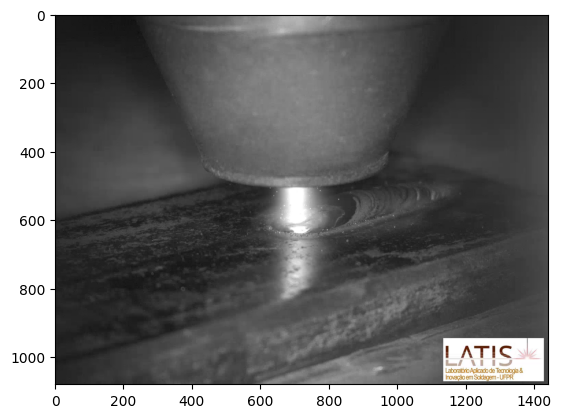

In [9]:
plt.imshow(sample) # image rendered from image tensor


### Preprocessing

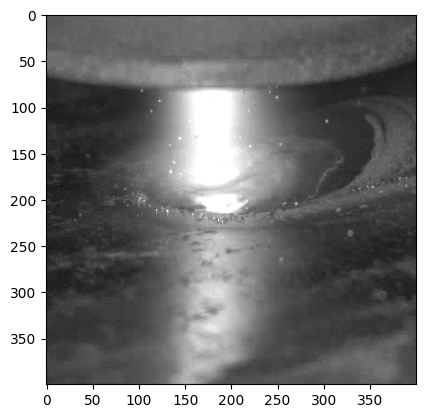

In [10]:
# leveraging the camera positioning fixed on the same point across
# the 9 depositions, it is possible to use a naive algorith to crop
# images by just finding by try and error a siutable size
# In this case, 400 x 400 pixels
plt.imshow(sample[425: 825, 525:925 , :]) 

In [11]:
experiments = ['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9']
cropped_images_dirs = {}

for e in experiments:
    cropped_images_dirs[e] = save_cropped_frames_to_directory(e)

cropped_images_dirs

{'L1': 'datasets/experimentos_taguchi/cropped_images/400p/L1',
 'L2': 'datasets/experimentos_taguchi/cropped_images/400p/L2',
 'L3': 'datasets/experimentos_taguchi/cropped_images/400p/L3',
 'L4': 'datasets/experimentos_taguchi/cropped_images/400p/L4',
 'L5': 'datasets/experimentos_taguchi/cropped_images/400p/L5',
 'L6': 'datasets/experimentos_taguchi/cropped_images/400p/L6',
 'L7': 'datasets/experimentos_taguchi/cropped_images/400p/L7',
 'L8': 'datasets/experimentos_taguchi/cropped_images/400p/L8',
 'L9': 'datasets/experimentos_taguchi/cropped_images/400p/L9'}

In [12]:
experiment_parameters = {
    'L1': {
        'current': 120,
        'nozzle_speed': 60,
        'mass_flow_rate': 10
    },
    'L2': {
        'current': 160,
        'nozzle_speed': 60,
        'mass_flow_rate': 15
    },
    'L3': {
        'current': 200,
        'nozzle_speed': 60,
        'mass_flow_rate': 20
    },
    'L4': {
        'current': 120,
        'nozzle_speed': 80,
        'mass_flow_rate': 10
    },
    'L5': {
        'current': 160,
        'nozzle_speed': 80,
        'mass_flow_rate': 15
    },
    'L6': {
        'current': 200,
        'nozzle_speed': 80,
        'mass_flow_rate': 20
    },
    'L7': {
        'current': 120,
        'nozzle_speed': 100,
        'mass_flow_rate': 10
    },
    'L8': {
        'current': 160,
        'nozzle_speed': 100,
        'mass_flow_rate': 15
    },
    'L9': {
        'current': 200,
        'nozzle_speed': 100,
        'mass_flow_rate': 20
    }
}

dataframes = []

for k,v in cropped_images_dirs.items():
    extracted_features = extract_features_from_images_dir(v)
    df = pd.DataFrame(extracted_features)
    df['current'] = experiment_parameters[k]['current']
    df['nozzle_speed'] = experiment_parameters[k]['nozzle_speed']
    df['mass_flow_rate'] = experiment_parameters[k]['mass_flow_rate']
    df['experiment'] = k
    dataframes.append(df)

merged_df = pd.concat(dataframes)

I0000 00:00:1775324365.292626  162472 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5215 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-04-04 14:39:29.402570: I external/local_xla/xla/service/service.cc:163] XLA service 0x79caf0003f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-04 14:39:29.402582: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2026-04-04 14:39:29.514144: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-04 14:39:30.775581: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300
I0000 00:00:1775324382.219577  169823 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at mos

In [13]:
images_index_limits = {
    'L1': {
        "lower": 1450,
        "upper": 5713
    },
    'L2': {
        "lower": 600,
        "upper": 4550
    },
    'L3': {
        "lower": 350,
        "upper": 4200
    },
    'L4': {
        "lower": 750,
        "upper": 3800
    },
    'L5': {
        "lower": 600,
        "upper": 3700
    },
    'L6': {
        "lower": 650,
        "upper": 3600
    },
    'L7': {
        "lower": 650,
        "upper": 2400
    },
    'L8': {
        "lower": 800,
        "upper": 2650
    },
    'L9': {
        "lower": 750,
        "upper": 2650
    }
}

filtered_extracted_features_dfs = []
for e in images_index_limits.keys():
    extracted_features = merged_df[merged_df['experiment'] == e].copy()
    filtered_extracted_features = extracted_features.iloc[images_index_limits[e]['lower']: images_index_limits[e]['upper'], :].copy()
    y = [get_spline_func(e)(_x) for _x in np.arange(0, 8, 8/len(filtered_extracted_features))]
    filtered_extracted_features['y'] = y
    filtered_extracted_features_dfs.append(filtered_extracted_features)

In [14]:
merged_filtered_extracted_features_df = pd.concat(filtered_extracted_features_dfs).reset_index(drop=True)
merged_filtered_extracted_features_df.to_csv("datasets/static_inceptionresnetv2_merged_df.csv", index=False)
merged_filtered_extracted_features_df.head()

,0,1,2,3,4,5,6,7,8,9,...,1531,1532,1533,1534,1535,current,nozzle_speed,mass_flow_rate,experiment,y
0,0.268740,2.139144,0.250135,1.119678,1.719419,2.526824,1.436541,1.199924,1.908662,2.700442,...,4.551702,0.975998,5.083746,0.915959,0.810865,120,60,10,L1,8.27
1,1.797193,1.111791,2.171830,1.170225,1.961134,3.888979,2.257810,2.499491,2.026833,2.083114,...,2.355335,1.154482,4.845751,2.037477,2.381801,120,60,10,L1,8.275047287583847
2,0.699182,1.457705,2.460773,0.657201,1.664176,4.082451,2.052771,2.159000,2.103463,1.817997,...,2.132757,0.692364,5.400849,1.505084,2.367985,120,60,10,L1,8.280094108153635
3,0.550797,1.931530,1.276285,1.708750,3.027601,2.558256,2.568470,1.674336,1.262541,2.066734,...,1.725715,2.406019,6.180463,2.243853,1.437320,120,60,10,L1,8.285139994695305
4,2.262296,0.768306,0.833527,1.734938,1.912504,3.626095,3.608762,1.741664,2.953330,2.291711,...,1.863139,1.339136,6.118917,1.452486,1.299811,120,60,10,L1,8.290184480194798
